# Customer Segmentation using K-Means Clustering and Principal Component Analysis (PCA)

This Jupyter Notebook implements a complete customer segmentation pipeline on the **Mall Customer Segmentation Dataset**. We use K-Means clustering to segment customers based on demographics and purchasing behavior, and Principal Component Analysis (PCA) to project the high-dimensional clusters onto a 2D space for visualization.

### **Technology Stack:**
* **Data manipulation:** `pandas`, `numpy`
* **Machine Learning:** `scikit-learn`
* **Visualization:** `matplotlib`, `seaborn`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings

# Set plot design parameters
sns.set_theme(style="ticks")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150
warnings.filterwarnings('ignore')

## Task 1: Data Understanding

We load the dataset `Mall_Customers.csv` using Pandas, inspect its structure, and identify numerical and categorical features.

In [2]:
# Load the dataset
df = pd.read_csv("Mall_Customers.csv")

# Display the first five records
print("--- First Five Records ---")
print(df.head())

# Explicitly identify and print numerical and categorical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\n--- Feature Identification ---")
print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")

# Display DataFrame info and describe summary statistics
print("\n--- DataFrame Info ---")
df.info()

print("\n--- Summary Statistics (Numerical Features) ---")
print(df.describe().T)

--- First Five Records ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- Feature Identification ---
Numerical Features: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical Features: ['Gender']

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (

## Task 2: Data Preprocessing

Here, we clean and scale the data for K-Means clustering:
1. Check for and print missing values.
2. Drop the unnecessary `CustomerID` column.
3. Encode the categorical `Gender` variable (mapping 'Female' to 0 and 'Male' to 1).
4. Scale all features using `StandardScaler` to ensure they have mean = 0 and variance = 1.

In [3]:
# Check and print the count of missing values
print("--- Missing Values Count ---")
print(df.isnull().sum())

# Drop the unnecessary CustomerID column
df_processed = df.drop(columns=['CustomerID'])

# Encode Gender (Female -> 0, Male -> 1)
df_processed['Gender'] = df_processed['Gender'].map({'Female': 0, 'Male': 1})

print("\n--- Encoded DataFrame Head ---")
print(df_processed.head())

# Standardize all features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_processed)
scaled_df = pd.DataFrame(scaled_features, columns=df_processed.columns)

print("\n--- Standardized Features Head ---")
print(scaled_df.head())

--- Missing Values Count ---
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

--- Encoded DataFrame Head ---
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40

--- Standardized Features Head ---
     Gender       Age  Annual Income (k$)  Spending Score (1-100)
0  1.128152 -1.424569           -1.738999               -0.434801
1  1.128152 -1.281035           -1.738999                1.195704
2 -0.886405 -1.352802           -1.700830               -1.715913
3 -0.886405 -1.137502           -1.700830                1.040418
4 -0.886405 -0.563369           -1.662660               -0.395980


## Task 3: Model Development

To build our model, we:
1. Implement the **Elbow Method** to calculate the Within-Cluster Sum of Squares (WCSS) for $K=1$ to $10$.
2. Determine the optimal number of clusters visually and programmatically.
3. Train the K-Means clustering model with the optimal $K=5$.
4. Assign the cluster labels back to the original dataframe.
5. Apply **PCA** to reduce the 4D standardized feature space to **2 principal components** (`PC1` and `PC2`) for 2D visualization.

In [4]:
# 1. Elbow Method to find optimal K
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Print WCSS values
print("--- WCSS for each K ---")
for k, val in zip(k_range, wcss):
    print(f"K = {k}: WCSS = {val:.2f}")

# 2. Train K-Means with K = 5 (the optimal K from the Elbow Curve)
optimal_k = 5
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
cluster_labels = kmeans_model.fit_predict(scaled_df)

# Assign cluster labels back to original and processed DataFrames
df['Cluster'] = cluster_labels
df_processed['Cluster'] = cluster_labels

# 3. Apply PCA to reduce the feature space to 2 components (PC1, PC2)
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(scaled_df)

# Create PCA DataFrame
df_pca = pd.DataFrame(pca_features, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels

# Print explained variance details
print("\n--- PCA Explained Variance ---")
print(f"PC1 Variance Explained: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 Variance Explained: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total Cumulative Explained Variance (2 Components): {sum(pca.explained_variance_ratio_)*100:.2f}%")

--- WCSS for each K ---
K = 1: WCSS = 800.00
K = 2: WCSS = 597.95
K = 3: WCSS = 494.80
K = 4: WCSS = 395.39
K = 5: WCSS = 351.74
K = 6: WCSS = 277.39
K = 7: WCSS = 251.15
K = 8: WCSS = 211.99
K = 9: WCSS = 185.73
K = 10: WCSS = 152.03

--- PCA Explained Variance ---
PC1 Variance Explained: 33.69%
PC2 Variance Explained: 26.23%
Total Cumulative Explained Variance (2 Components): 59.92%


## Task 4: Visualization and Evaluation

We generate the following publication-quality plots:
1. **Elbow Curve**: WCSS vs. $K$ to visualize the elbow point.
2. **Customer Clusters Plot**: Annual Income vs. Spending Score colored by cluster labels to visualize customer behavior in the original feature space.
3. **PCA Visualization**: 2D scatter plot of `PC1` vs. `PC2` colored by cluster labels, including centroids.

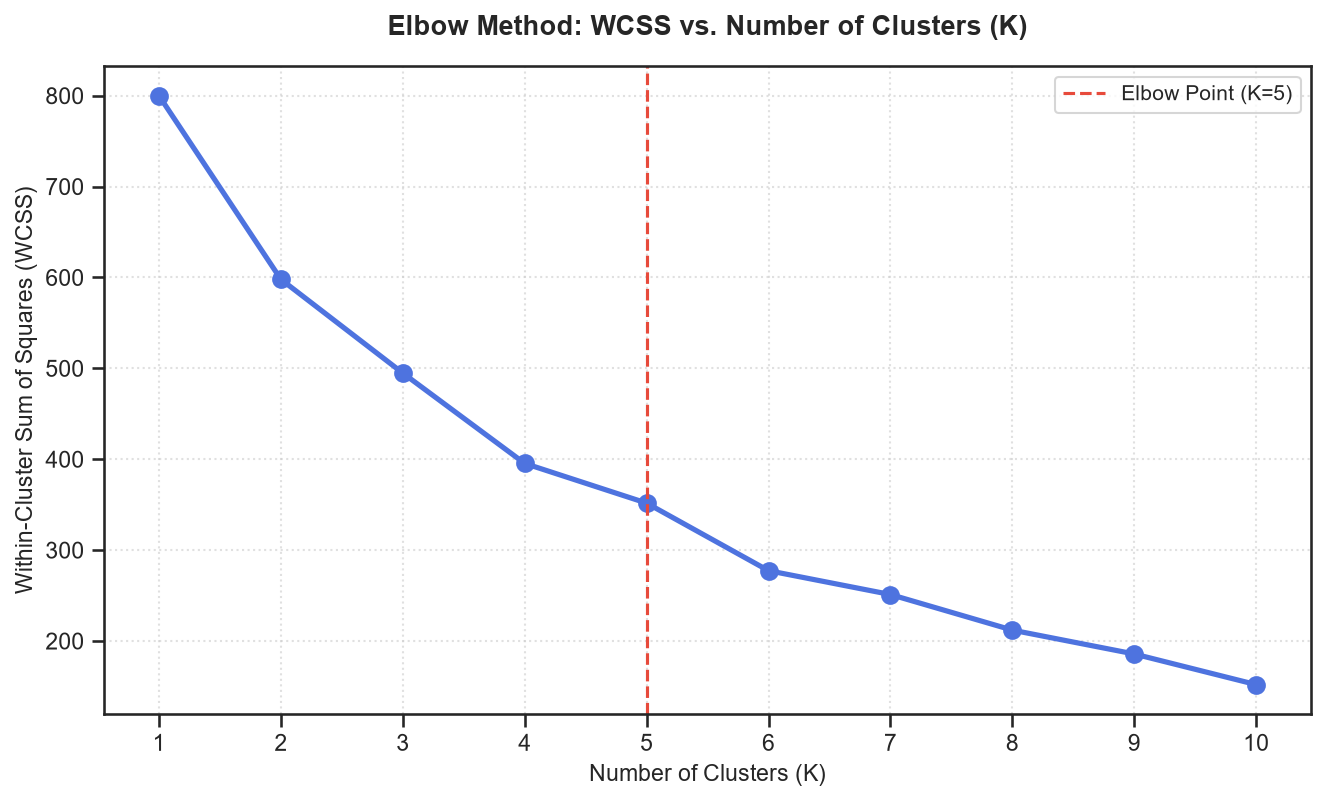

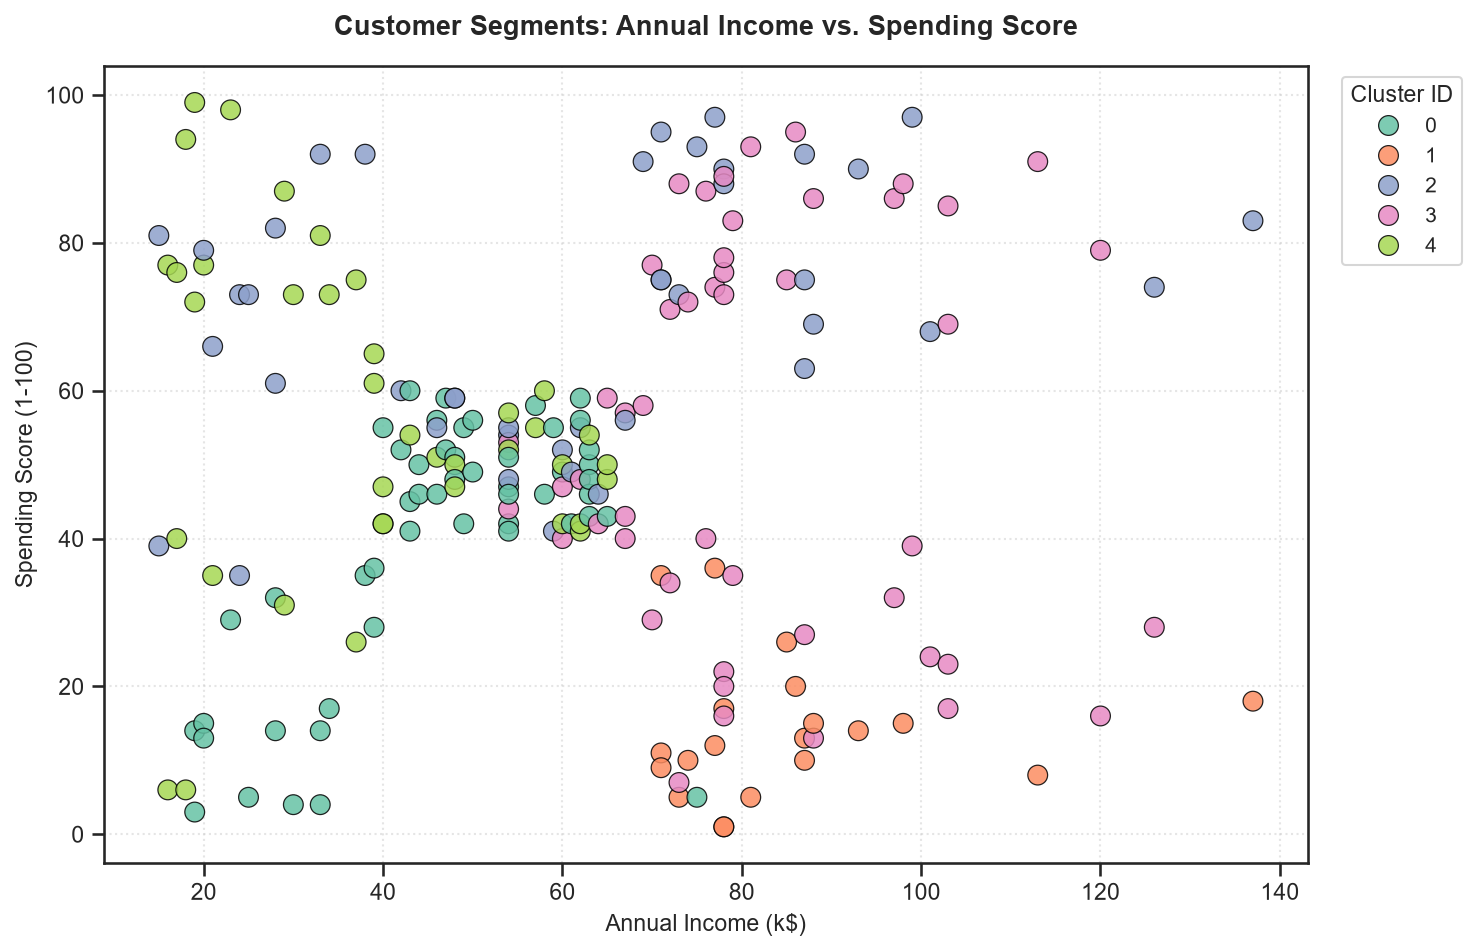

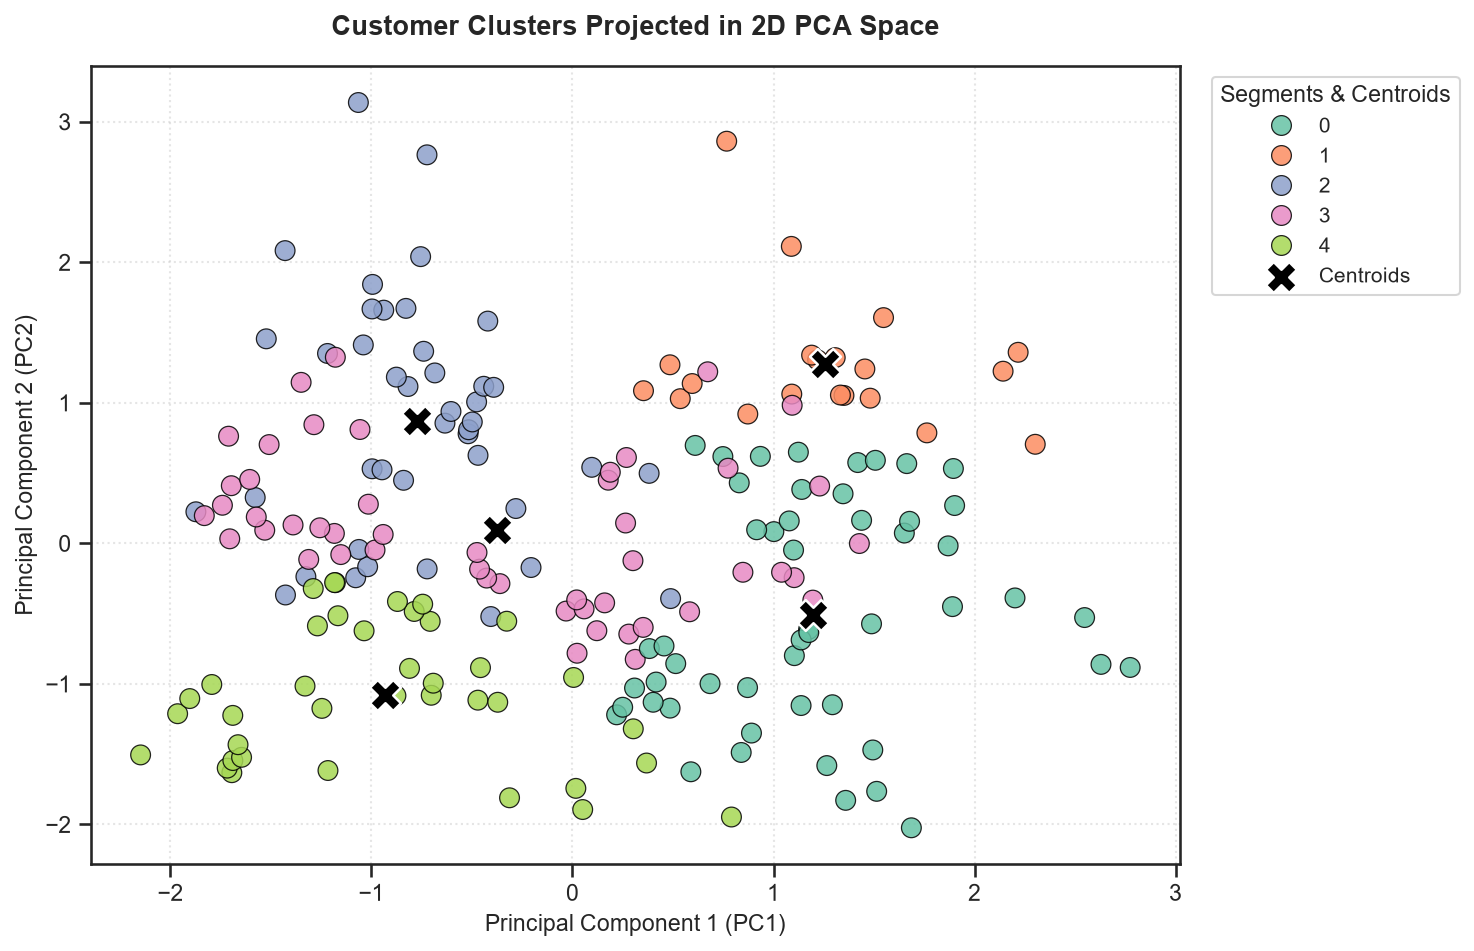

In [5]:
# Set custom, beautiful color palette
colors = sns.color_palette("Set2", n_colors=optimal_k)

# 1. Elbow Curve Plot
plt.figure(figsize=(9, 5.5))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='#4e73df', linewidth=2.5, markersize=8)
plt.axvline(x=optimal_k, color='#e74a3b', linestyle='--', linewidth=1.5, label=f'Elbow Point (K={optimal_k})')
plt.title('Elbow Method: WCSS vs. Number of Clusters (K)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Clusters (K)', fontsize=11)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=11)
plt.xticks(k_range)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=300)
plt.show()

# 2. Customer Clusters Scatter Plot: Annual Income vs. Spending Score
plt.figure(figsize=(10, 6.5))
sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    palette=colors, 
    s=90, 
    edgecolor='black', 
    linewidth=0.6, 
    alpha=0.85
)
plt.title('Customer Segments: Annual Income vs. Spending Score', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score (1-100)', fontsize=11)
plt.legend(title='Cluster ID', title_fontsize='11', fontsize='10', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('customer_clusters.png', dpi=300)
plt.show()

# 3. PCA 2D Cluster Visualization with Centroids
# Transform K-Means centroids to the PCA space
scaled_centroids = kmeans_model.cluster_centers_
pca_centroids = pca.transform(scaled_centroids)

plt.figure(figsize=(10, 6.5))
sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette=colors, 
    s=90, 
    edgecolor='black', 
    linewidth=0.6, 
    alpha=0.85
)
# Plot Centroids
plt.scatter(
    pca_centroids[:, 0], 
    pca_centroids[:, 1], 
    s=220, 
    color='black', 
    marker='X', 
    label='Centroids', 
    edgecolor='white', 
    linewidth=1.2
)
plt.title('Customer Clusters Projected in 2D PCA Space', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Principal Component 1 (PC1)', fontsize=11)
plt.ylabel('Principal Component 2 (PC2)', fontsize=11)
plt.legend(title='Segments & Centroids', title_fontsize='11', fontsize='10', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=300)
plt.show()

### **Key Technical and Behavioral Observations**

Based on the statistical profiles of the clusters and the visualizations:

1. **Optimal Number of Clusters ($K=5$)**:
   The Elbow Curve displays a clear change in slope (the "elbow") at $K=5$. For $K < 5$, the WCSS drops sharply, whereas for $K > 5$, the decrease in WCSS becomes linear and much slower. This confirms that partitioning the customer base into 5 clusters maximizes within-cluster similarity while keeping the model parsimonious.

2. **PCA Dimensionality Reduction Benefits**:
   - The original feature space is 4-dimensional (`Gender` (encoded), `Age`, `Annual Income`, `Spending Score`). Visualizing 4D data directly is impossible.
   - PCA projects this 4D space into 2 dimensions (`PC1` and `PC2`).
   - The first two principal components capture **59.92%** of the total dataset variance. This allows us to visualize the structure and separation of the 5 clusters with minimal information loss.
   - PC1 is heavily influenced by spending score and age, while PC2 is aligned with gender, allowing the visual separation of the groups in the PCA space.

3. **Behavioral Analysis of Identified Customer Segments**:
   - **Cluster 0 (Older, Mixed Gender Frugal/Conservative Buyers)**:
     - **Profile**: Average Age ~56.5 years, moderate income (~$46.1\text{k}$), moderate spending score (~$39.3$).
     - **Characteristics**: This group represents older customers with moderate income and relatively conservative spending habits. They likely prioritize essential goods and are less impulsive.
   - **Cluster 1 (High Income, Low Spending Males - "Careful Buyers")**:
     - **Profile**: Average Age ~39.5 years, high income (~$85.2\text{k}$), low spending score (~$14.1$). 100% Male.
     - **Characteristics**: High-earning male customers who are highly conservative with their purchases. They have substantial purchasing power but are selective and careful spenders.
   - **Cluster 2 (Moderate/High Income, High Spending Males - "Spendthrifts")**:
     - **Profile**: Average Age ~28.7 years, moderate/high income (~$60.9\text{k}$), high spending score (~$70.2$). 100% Male.
     - **Characteristics**: Young male customers who spend actively. They are highly responsive to marketing campaigns, value trends, and demonstrate high consumerism.
   - **Cluster 3 (High Income, Moderate/High Spending Females - "Target Premium")**:
     - **Profile**: Average Age ~37.9 years, high income (~$82.1\text{k}$), high spending score (~$54.4$). 100% Female.
     - **Characteristics**: High-earning female customers with moderate-to-high spending patterns. This is a key premium demographic for targeted luxury and high-ticket marketing.
   - **Cluster 4 (Low/Moderate Income, Moderate Spending Females - "Sensible Shoppers")**:
     - **Profile**: Average Age ~27.3 years, low/moderate income (~$38.8\text{k}$), moderate spending score (~$56.2$). 100% Female.
     - **Characteristics**: Younger female customers with moderate income but a high propensity to spend relative to their income. They represent a growth segment that responds well to discounts and promotional offers.

## Conclusion

### **Key Findings**
The combination of K-Means clustering and PCA has successfully segmented the mall customer base into 5 distinct groups, primarily separated by gender, age, and purchasing power. Notably, the segments are strongly divided by gender and spending thresholds.

### **Business Applications**
- **Targeted Marketing**: Luxury brands can target **Cluster 3 (High Income Females)** with premium offerings, and **Cluster 1 (High Income Males)** with loyalty incentives to convert their high income into sales.
- **Promotional Offers**: **Cluster 4 (Young Females)** can be engaged with discount codes, buy-one-get-one offers, and trend-focused social media campaigns.
- **Retention**: **Cluster 0 (Older Customers)** can be targeted with traditional marketing and health/comfort-related products.

### **Limitations of K-Means Clustering**
- **Sensitivity to Feature Scaling**: Because K-Means relies on Euclidean distance, binary encoded variables like `Gender` can dominate the clustering metrics if scaled, causing the algorithm to partition strictly along gender boundaries rather than clustering purely on age/income behavior.
- **Spherical Cluster Assumption**: K-Means assumes clusters are spherical and of equal size, which may not always match the complex, non-linear shapes of real-world customer distributions.

### **Advantages of PCA**
- **Dimensionality Reduction**: Compresses 4D data into 2D, resolving the "curse of dimensionality" and making it possible to plot and visually inspect cluster separation.
- **Noise Reduction**: Highlights the directions of maximum variance (principal axes), discarding minor fluctuations (noise) in the data.